In [ ]:
import numpy as np
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
import torch
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import pandas as pd
from collections import defaultdict
import scipy

from plt_dict import matplotlib_update

matplotlib_update()

rng = np.random.default_rng(seed=123)

In [2]:
def setup_device():
    try:
        import torch_directml

        device = torch_directml.device()
        backend = "directml"    
    except ImportError:
        if torch.cuda.is_available():
            device = torch.device("cuda")
            backend = "cuda"
        else:
            device = torch.device("cpu")
            backend = "cpu"
    return device

device = setup_device()

In [3]:
class SimpleNN(nn.Module):
    def __init__(self, d):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(d * d, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, d),
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.layers(x)
        return x

In [4]:

def random_matrix_with_condition(m, n=None, cond_number=10.0):
    """
    Generate an m x n random matrix with approximate condition = cond_number,
    using singular values drawn uniformly between 1/sqrt(cond) and sqrt(cond).
    """
    if n is None:
        n = m
        
    # random orthogonal factors from normal distribution
    U, _ = np.linalg.qr(np.random.randn(m, m))
    V, _ = np.linalg.qr(np.random.randn(n, n))

    min_dim = min(m, n)

    # limits for uniform singular values
    s_min = 1.0 / np.sqrt(cond_number)
    s_max = np.sqrt(cond_number)

    # draw singular values uniform in [s_min, s_max]
    s = np.concatenate([np.array([s_min, s_max]), np.random.uniform(low=s_min, high=s_max, size=min_dim-2)])

    # build Sigma
    Sigma = np.zeros((m, n))
    Sigma[:min_dim, :min_dim] = np.diag(s)

    return U @ Sigma @ V.T

In [5]:
def generate_matrix(d, block_size, eps=None, lam=1, schur=False, cond=100):
    """
    Generuje macierz testową o rozmiarze `d x d` z kontrolowaną strukturą.

    Parametry:
    - d (int): wymiar macierzy (liczba wierszy/kolumn).
    - block_size (int): liczba pozycji na nadprzekątnej, które zostaną ustawione
        na 1 (losowo wybrane indeksy). Używane do budowy macierzy Jordanowskiej.
    - mode (str): tryb generacji macierzy pomocniczej `S`. Obsługiwane wartości:
        "random", "int", "upper", "lower", "ortho". Określa, jakiego rodzaju
        macierz S zostanie wygenerowana (np. ortogonalna, trójkątna itp.).
    - eps (float|None): jeśli nie None, dodaje małą losową perturbację do macierzy
        J (skaluje losowymi wartościami z [0, eps)). Przydatne do testów stabilności.
    - lam (float): wartość dodawana do elementów diagonalnych macierzy J (domyślnie 1).
    - value_range (int|float|None): skala wartości używana przy generacji macierzy S;
        jeśli None, wartość dobierana jest zależnie od `mode`.
    - schur (bool): jeśli True, zwraca postać Schura macierzy X zamiast X bezpośrednio.

    Zwraca:
    - X (np.ndarray): macierz wynikowa rozmiaru (d, d). Jeśli `schur`==True, zwracana
        jest macierz otrzymana z dekompozycji Schura.

    Uwaga:
    Funkcja tworzy macierz J (prawie Jordanowską) z nadprzekątną ustawioną zgodnie
    z `block_size`, a następnie wykonuje podobieństwo X = S @ J @ S^{-1}, gdzie S
    jest generowane według `mode`.
    """
    indexes = np.random.choice(d-1, size=block_size, replace=False)
    # indexes = list(range(block_size))
    super_diag = np.zeros(d-1)
    for index in indexes:
        super_diag[index] = 1
    J = lam * np.eye(d) + np.diag(super_diag, k=1)
    if eps is not None:
        J += eps * np.random.randn(d, d)

    S = random_matrix_with_condition(d, cond_number=cond)
    X = S @ J @ np.linalg.inv(S)
    if schur:
        return scipy.linalg.schur(X)[0]
    else:
        return X


def generate_testset(d, size_per_class, mode="random", eps=None, cond=100):
    """
    Generuje zbiór testowy macierzy wraz z etykietami klas.

    Parametry:
    - d (int): wymiar macierzy (liczba klas również wynika z `d`).
    - size_per_class (int): liczba przykładów (macierzy) generowanych dla każdej klasy.
    - mode (str): tryb przekazywany dalej do `generate_matrix` (jak wyżej).
    - eps (float|None): opcjonalna perturbacja przekazywana do `generate_matrix`.
    - schur (bool): jeśli True, każda macierz będzie zwrócona w postaci Schura.

    Zwraca:
    - X (np.ndarray): tablica kształtu `(size_per_class * d, d, d)`, gdzie pierwszym
      wymiarem indeksujemy próbki.
    - y (list[int]): lista etykiet (0..d-1) odpowiadająca klasom każdej macierzy w X.

    Zachowanie:
    Dla każdej etykiety `label` od 0 do `d-1` generowane jest `size_per_class`
    macierzy przy użyciu `generate_matrix(d, label, ...)`. Etykieta przypisywana jest
    zgodnie z wartością `label` (może reprezentować np. rozmiar bloku/Jordanowską pozycję).
    """
    X = np.ndarray(shape=(size_per_class * (d-1), d, d))
    y = []

    idx = 0
    for label in range(1, d):
        for _ in range(size_per_class):
            X[idx] = generate_matrix(d, label, eps=eps, cond=cond)
            idx += 1
            y.append(label)

    return X, y

In [6]:
def compute_accuracies(model, eps):
    accuracies = {}
    for cond in np.logspace(0, 5, num=25):
        X, y = generate_testset(5, size_per_class=1000, eps=eps, cond=cond)
        X = torch.tensor(X, dtype=torch.float32).to(device)
        model.eval()

        with torch.no_grad():
            outputs = model(X)
            y_predicted = torch.argmax(outputs, dim=1).cpu().numpy()
        accuracy = accuracy_score(y, y_predicted)
        accuracies[cond] = accuracy
    return accuracies

In [7]:
model = SimpleNN(d=5).to(device)
model.load_state_dict(torch.load("sandbox/model_4a/1_100.pth"))

model2 = SimpleNN(d=5).to(device)
model2.load_state_dict(torch.load("sandbox/model_4a/1_1000.pth"))

C:\Users\micha\AppData\Local\Temp\ipykernel_10088\3539872500.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("sandbox/model_4a/1_100.pth

<All keys matched successfully>

In [8]:
accuracies = compute_accuracies(model, None)
accuracies_eps = compute_accuracies(model, 0.01)

accuracies2 = compute_accuracies(model2, None)
accuracies_eps2 = compute_accuracies(model2, 0.01)

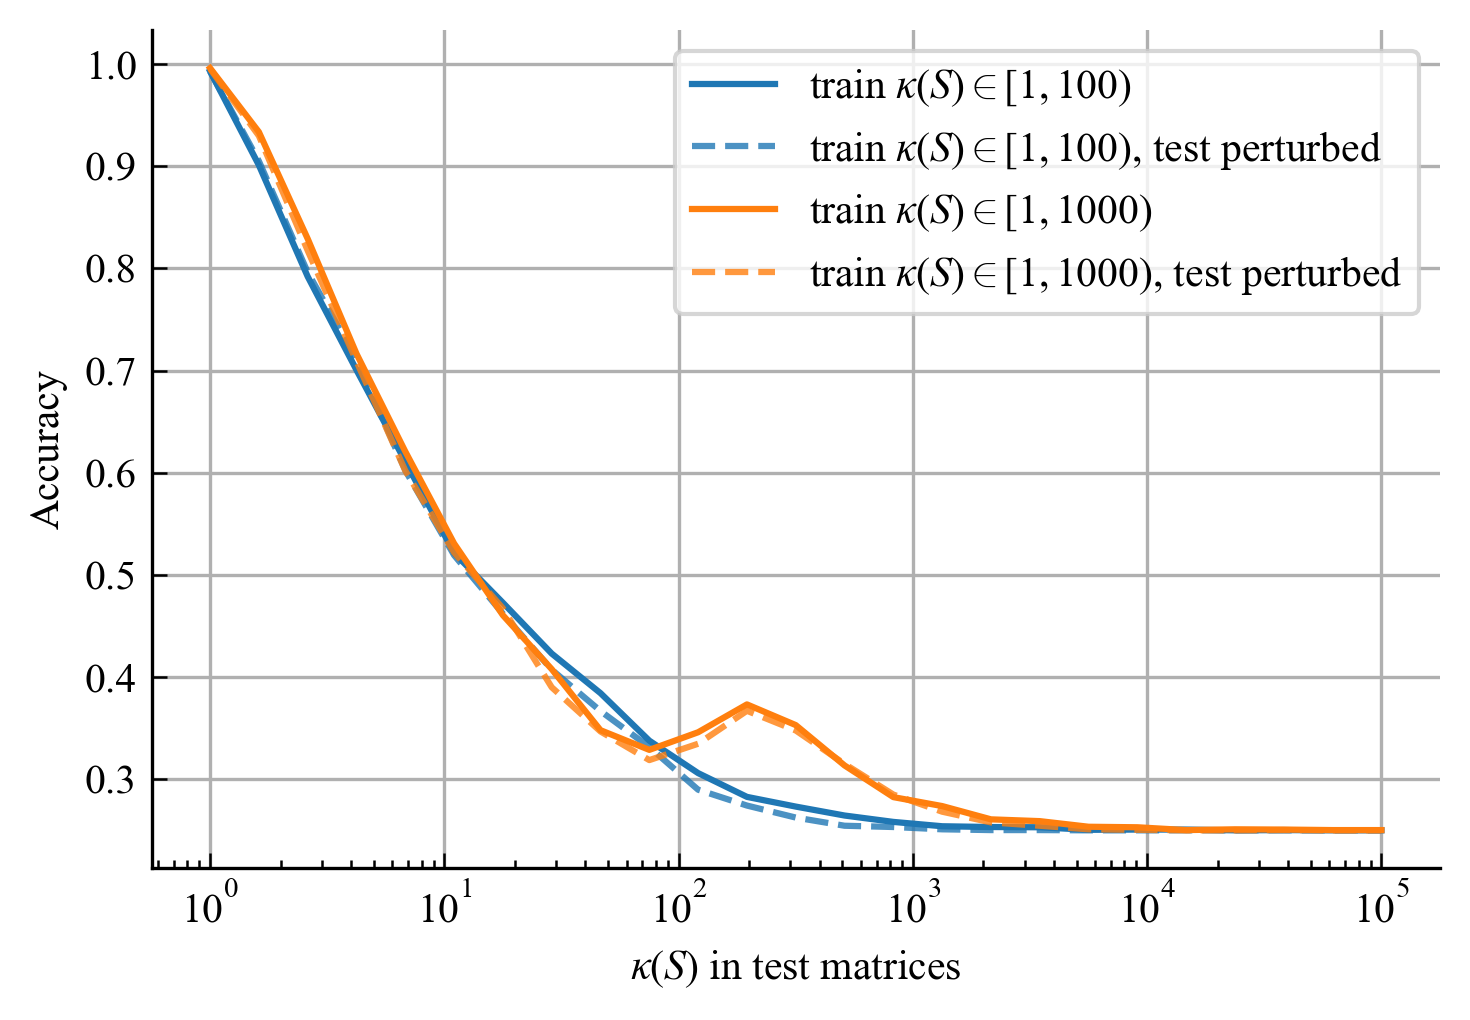

In [9]:
fig, ax1 = plt.subplots()

# Plot accuracy lines with enhanced styling
ax1.plot(list(accuracies.keys()), list(accuracies.values()),
         label='train $\\kappa(S) \\in [1, 100)$', color='#1f77b4', )

ax1.plot(list(accuracies_eps.keys()), list(accuracies_eps.values()),
         label='train $\\kappa(S) \\in [1, 100)$, test perturbed', color='#1f77b4', linestyle='--', alpha=0.8)

ax1.plot(list(accuracies2.keys()), list(accuracies2.values()),
         label='train $\\kappa(S) \\in [1, 1000)$', color='#ff7f0e')

ax1.plot(list(accuracies_eps2.keys()), list(accuracies_eps2.values()),
         label='train $\\kappa(S) \\in [1, 1000)$, test perturbed', color='#ff7f0e', linestyle='--', alpha=0.8)

ax1.set_xscale('log')
ax1.set_xlabel('$\\kappa(S)$ in test matrices')
ax1.set_ylabel('Accuracy')

# Enhanced grid
ax1.grid(True)
ax1.legend()
# ax1.set_axisbelow(True)

# # Improve legend
# legend = ax1.legend(loc='best', fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
# legend.get_frame().set_linewidth(1)

# # Set spine visibility and style
# ax1.spines['top'].set_visible(False)
# ax1.spines['right'].set_visible(False)
# ax1.spines['left'].set_linewidth(1.2)
# ax1.spines['bottom'].set_linewidth(1.2)

# # Improve tick labels
# ax1.tick_params(labelsize=11, width=1.2, length=6)

plt.tight_layout()
plt.savefig("latex/images/jordan_4a.pdf")
plt.show()
